<a href="https://colab.research.google.com/github/gopalstud86/GenAI-Assignments/blob/main/Bronze%20Badge%20Assignments/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

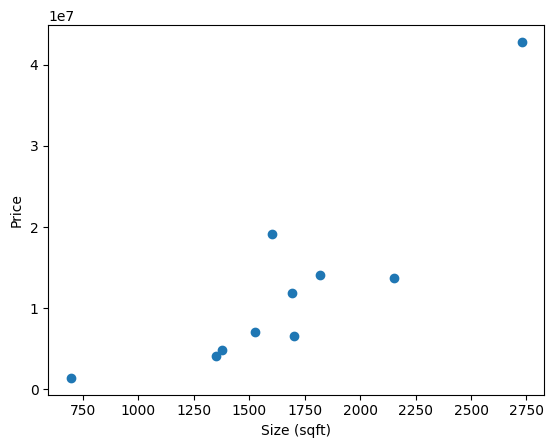

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

#dataset_csv = "Bronze Badge Assignments/Datasets/house_price_dataset.csv"
dataset_url = "https://raw.githubusercontent.com/gopalstud86/GenAI-Assignments/refs/heads/main/Bronze%20Badge%20Assignments/Datasets/house_price_dataset.csv"

df = pd.read_csv(dataset_url)
df.head()
#pd.DataFrame(df)


plt.scatter(df["area_sqft"], df["house price"])
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.show()



In [12]:
X = df[["area_sqft", "bedrooms"]]
y = df["house price"]

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [15]:
model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")

new_house = [[1600, 3]]
new_house_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_house_scaled)
print("Predicted Price:", predicted_price[0])

Predicted Price: 8732932.992842847


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


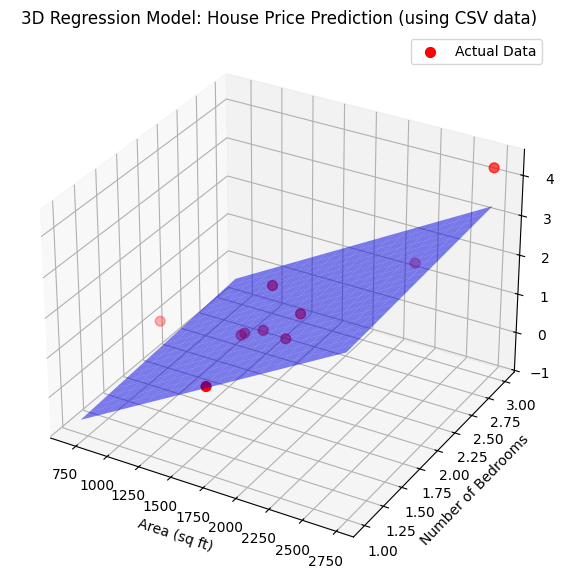

In [16]:
# Install matplotlib if not already installed:
# pip install matplotlib scikit-learn numpy pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 1. Define Features and Target from the loaded DataFrame
# -----------------------------
X = df[["area_sqft", "bedrooms"]]
y = df["house price"]


# -----------------------------
# 2. Train Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# 3. Create Grid for 3D Surface
# -----------------------------
area_range = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 20)
bedroom_range = np.linspace(df["bedrooms"].min(), df["bedrooms"].max(), 20)
area_grid, bedroom_grid = np.meshgrid(area_range, bedroom_range)

# Predict prices on the grid
price_pred = model.predict(
    np.c_[area_grid.ravel(), bedroom_grid.ravel()]
).reshape(area_grid.shape)

# -----------------------------
# 4. Plot 3D Visualization
# -----------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot of actual data
ax.scatter(df["area_sqft"], df["bedrooms"], df["house price"],
           color="red", label="Actual Data", s=50)

# Regression surface
ax.plot_surface(area_grid, bedroom_grid, price_pred,
                color="blue", alpha=0.5)

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Number of Bedrooms")
ax.set_zlabel("House Price")
ax.set_title("3D Regression Model: House Price Prediction (using CSV data)")

plt.legend()
plt.show()